## 1. Neural Network Regression — K-fold with NAVG & KEEP_LAST_PERCENT

This notebook mirrors the structure of `reg_RF_tutorial.ipynb`, but uses a PyTorch
Neural Network (MLP) for **regression** instead of Random Forest.

Key settings (from hyperparameter search):

- KEEP_LAST_PERCENT = 50  
- NAVG              = 280  
- HIDDEN_LAYERS     = 1  
- HIDDEN_SIZE       = 72  
- LEARNING_RATE     = 1.23e-5  
- WEIGHT_DECAY      = 0.00018  
- DROPOUT_IO        = 0.26  
- DROPOUT_HIDDEN    = 0.07  


## 2. Imports & Global Config

In [1]:
import os
import logging
from pathlib import Path
from typing import Any, List, Tuple, Dict
from collections import defaultdict

import numpy as np
import pandas as pd

import torch as T
import torch.nn as nn

from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, accuracy_score, matthews_corrcoef
from scipy.stats import pearsonr

from IPython.display import display

# Reproducibility
random_state = 42
np.random.seed(random_state)
T.manual_seed(random_state)

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

## 3. Load Experimental & MD Data, Merge on Sequence

Assumes:
- `exp_data_all.csv` contains at least: `sequence`, `bind_avg`  
- `rawdat.csv` contains MD features plus `sequence` and `run`  


In [2]:
# ID and label columns
id_col    = "sequence"
label_col = "bind_avg"

# --- Experimental data ---
df_exp = pd.read_csv("exp_data_all.csv")
ref_data = df_exp[[id_col, label_col]].copy()
print("Experimental data:", ref_data.shape)
display(ref_data.head())

# --- MD / feature data ---
usecols = [
    "sequence", "run",
    "VDWAALS", "EEL", "EGB", "ESURF",
    "HB Energy", "Hydrophobic Energy", "Pi-Pi Energy",
    "Delta_Entropy"
]

df_md = pd.read_csv("rawdat.csv", usecols=usecols)
feature_data = df_md.copy()
print("Feature data:", feature_data.shape)
display(feature_data.head())

# --- Merge on sequence ---
df_merged = pd.merge(feature_data, ref_data, on=id_col, how="inner")
print("Merged data:", df_merged.shape)
display(df_merged.head())

# Shuffle merged rows
df_merged = df_merged.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
print("Merged (shuffled):", df_merged.shape)

Experimental data: (168, 2)


,sequence,bind_avg
0,GAGGAAGCAGCCCTCGCCCCTGTCGGTGGAAAGAAG,-0.758634
1,GCAGCCGAGGCGGAGAGAGAGAGAGGACAGCTTACG,-1.003319
2,ATCTGATCAAAACAACGAATTCCAAAACAAAGTAAT,-0.800322
3,CCAATATTCCTTTGTGAGACCCTCCACAAATGCTAA,-0.941242
4,GAGGACGCGAACCGGCACGCTGCGCCTTTAAGGAGT,-0.684116


Feature data: (272160, 10)


,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy
0,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-252.110,-1886.830,1841.253,-36.482,-1.940432,-165.447020,-1.655191e-03,-26.046553
1,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-238.510,-1881.424,1835.847,-36.023,-2.003962,-155.422935,-4.708262e-02,-24.150637
2,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-246.721,-1895.687,1851.589,-35.802,-2.269901,-142.386371,-5.901517e-29,-24.329875
3,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-235.671,-1857.573,1814.002,-34.799,-2.838678,-147.918585,-3.236084e-07,-23.615145
4,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-230.214,-1897.268,1847.934,-34.391,-2.810414,-151.012478,-1.784784e-05,-23.698348


Merged data: (272160, 11)


,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg
0,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-252.110,-1886.830,1841.253,-36.482,-1.940432,-165.447020,-1.655191e-03,-26.046553,1.531336
1,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-238.510,-1881.424,1835.847,-36.023,-2.003962,-155.422935,-4.708262e-02,-24.150637,1.531336
2,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-246.721,-1895.687,1851.589,-35.802,-2.269901,-142.386371,-5.901517e-29,-24.329875,1.531336
3,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-235.671,-1857.573,1814.002,-34.799,-2.838678,-147.918585,-3.236084e-07,-23.615145,1.531336
4,GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC,9,-230.214,-1897.268,1847.934,-34.391,-2.810414,-151.012478,-1.784784e-05,-23.698348,1.531336


Merged (shuffled): (272160, 11)


## 4. Initial Train/Test Split by Sequence (80/20)

We split at the **sequence level** so that sequences in test are not seen in training.


In [3]:
test_percentage = 0.20

unique_seqs = df_merged[id_col].unique()
np.random.seed(random_state)
np.random.shuffle(unique_seqs)

n_train = int((1.0 - test_percentage) * len(unique_seqs))

train_seqs = unique_seqs[:n_train]
test_seqs  = unique_seqs[n_train:]

df_train = df_merged[df_merged[id_col].isin(train_seqs)].copy()
df_test  = df_merged[df_merged[id_col].isin(test_seqs)].copy()

print("Train shape:", df_train.shape)
print("Test  shape:", df_test.shape)

# Save initial split (optional, for traceability)
df_train.to_csv("reg_trn_final.csv", index=False)
df_test.to_csv("reg_tst_preprocess.csv", index=False)

Train shape: (217080, 11)
Test  shape: (55080, 11)


## 5. KEEP_LAST_PERCENT = 50

For each sequence, keep only the last 50% of rows (e.g., later frames / runs).


In [4]:
KEEP_LAST_PERCENT = 50  # from hyperparameter search

df_sorted = df_train.copy()

group_sizes = df_sorted.groupby(id_col)[id_col].transform("size")
cumcount    = df_sorted.groupby(id_col).cumcount()

n_keep = (group_sizes * (KEEP_LAST_PERCENT / 100.0)).astype(int)
n_keep = n_keep.mask(n_keep < 1, 1)  # at least 1 row if fraction > 0

mask = cumcount >= (group_sizes - n_keep)
df_train = df_sorted[mask].reset_index(drop=True)

print("After KEEP_LAST_PERCENT:", df_train.shape)
display(df_train.head())

After KEEP_LAST_PERCENT: (108540, 11)


,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg
0,CTCAGCGATGAGGAACACGCGGAAGTGTGGCCGGGC,9,-212.449,-1900.566,1850.943,-32.912,-4.040363,-153.223894,-2.483081,-23.837823,0.268219
1,CTCAGCGATGAGGAACACGCGGAAGTGTGGCCGGGC,2,-226.304,-1869.881,1823.182,-35.581,-4.181287,-153.599485,-3.569535,-24.600280,0.268219
2,CTCAGCGATGAGGAACACGCGGAAGTGTGGCCGGGC,19,-233.835,-1907.332,1859.783,-33.728,-3.003916,-151.536409,-7.778470,-23.408043,0.268219
3,CTCAGCGATGAGGAACACGCGGAAGTGTGGCCGGGC,2,-209.899,-1897.676,1847.118,-32.079,-3.788527,-148.943471,-4.673301,-21.829611,0.268219
4,CTCAGCGATGAGGAACACGCGGAAGTGTGGCCGGGC,17,-219.946,-1884.790,1840.539,-31.620,-1.630182,-144.254074,-3.794339,-21.031503,0.268219


## 6. NAVG = 280 — Average Numeric Features Per Sequence

Randomly shuffle rows within a sequence, group them into chunks of size 280,
and average numeric features in each chunk.

Each chunk → one "mutant-level" row.


In [5]:
NAVG = 280  # from hyperparameter search

def average_features_for_sequence(
    df: pd.DataFrame,
    navg: int,
    id_col: str,
    label_col: str,
    random_state: int
) -> pd.DataFrame:
    """Shuffle a sequence's rows, chop into chunks of size `navg`, and average numeric features."""
    if df.empty:
        return pd.DataFrame(columns=df.columns)

    df_shuf = df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    n_rows = len(df_shuf)
    chunks = []

    numeric_cols = df_shuf.select_dtypes(include=[np.number]).columns.tolist()
    if id_col in numeric_cols:
        numeric_cols.remove(id_col)
    if label_col in numeric_cols:
        numeric_cols.remove(label_col)

    for start in range(0, n_rows, navg):
        end = min(start + navg, n_rows)
        sub = df_shuf.iloc[start:end]

        row = {}
        row[id_col]    = sub[id_col].iloc[0]
        row[label_col] = sub[label_col].iloc[0]
        for col in numeric_cols:
            row[col] = sub[col].mean()

        chunks.append(row)

    return pd.DataFrame(chunks)

def average_features_for_mutants(
    df: pd.DataFrame,
    navg: int,
    id_col: str,
    label_col: str,
    random_state: int
) -> pd.DataFrame:
    all_chunks = []
    for seq, group in df.groupby(id_col):
        chunk_df = average_features_for_sequence(group, navg, id_col, label_col, random_state)
        all_chunks.append(chunk_df)
    if not all_chunks:
        return pd.DataFrame(columns=df.columns)
    return pd.concat(all_chunks, ignore_index=True)

df_train_avg = average_features_for_mutants(
    df_train,
    navg=NAVG,
    id_col=id_col,
    label_col=label_col,
    random_state=random_state
)

print("After NAVG averaging:", df_train_avg.shape)
display(df_train_avg.head())

After NAVG averaging: (402, 11)


,sequence,bind_avg,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy
0,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,1.172119,9.632143,-209.099271,-1889.517214,1842.585436,-31.975239,-13.561023,-139.275830,-2.816412,-22.455197
1,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,1.172119,11.325000,-208.715557,-1887.639321,1841.001157,-31.838875,-13.620140,-139.007266,-2.570618,-22.378025
2,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,1.172119,10.432000,-210.443612,-1885.036092,1838.558976,-31.871260,-13.317579,-139.523219,-2.689322,-22.440119
3,AACCTAAAACAAAAAATCTATTATCTGATTGCAGGT,-0.378805,10.414286,-199.388993,-1917.369529,1868.276746,-31.620850,-3.523818,-135.235846,-4.342863,-21.560128
4,AACCTAAAACAAAAAATCTATTATCTGATTGCAGGT,-0.378805,11.017857,-200.603825,-1918.399182,1869.324493,-31.919261,-3.539775,-136.631687,-4.690616,-21.607584


## 7. Compute Mean/Std, Save, and Standardize

Compute Z-score stats on training (averaged) data and apply them to get
a standardized training table.


In [6]:
from typing import Tuple

def compute_mean_std(
    df: pd.DataFrame,
    id_col: str,
    label_col: str
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if id_col in numeric_cols:
        numeric_cols.remove(id_col)
    if label_col in numeric_cols:
        numeric_cols.remove(label_col)
    means = [(c, df[c].mean()) for c in numeric_cols]
    stds  = [(c, df[c].std())  for c in numeric_cols]
    return (
        pd.DataFrame(means, columns=["colname", "mean"]),
        pd.DataFrame(stds,  columns=["colname", "std"])
    )

def save_mean_std(mean_df: pd.DataFrame, std_df: pd.DataFrame, filename: str) -> None:
    merged = pd.merge(mean_df, std_df, on="colname")
    merged.to_csv(filename, index=False)

def load_mean_std(filename: str) -> Dict[str, Tuple[float, float]]:
    df = pd.read_csv(filename)
    stats = {}
    for _, row in df.iterrows():
        stats[row["colname"]] = (row["mean"], row["std"])
    return stats

def apply_standardization(
    df: pd.DataFrame,
    stats: Dict[str, Tuple[float, float]],
    id_col: str,
    label_col: str
) -> pd.DataFrame:
    df_std = df.copy()
    for col, (m, s) in stats.items():
        if col in df_std.columns and s not in (0, None) and not np.isnan(s):
            df_std[col] = (df_std[col] - m) / s
    return df_std

# Compute and save stats
mean_df, std_df = compute_mean_std(df_train_avg, id_col, label_col)
save_mean_std(mean_df, std_df, "reg_train_mean_std.csv")

# Apply standardization
stats_dict = load_mean_std("reg_train_mean_std.csv")
df_train_std = apply_standardization(df_train_avg, stats_dict, id_col, label_col)

print("Standardized training data:", df_train_std.shape)
display(df_train_std.head())

Standardized training data: (402, 11)


,sequence,bind_avg,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy
0,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,1.172119,-2.797853,-0.350663,0.891499,-0.828914,-0.099992,-0.993413,-0.078806,0.296857,-0.547173
1,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,1.172119,2.594449,-0.312523,1.100077,-1.022562,0.025180,-1.004207,-0.043614,0.621551,-0.449631
2,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,1.172119,-0.250047,-0.484288,1.389218,-1.321073,-0.004547,-0.948965,-0.111224,0.464743,-0.528115
3,AACCTAAAACAAAAAATCTATTATCTGATTGCAGGT,-0.378805,-0.306473,0.614518,-2.202065,2.311362,0.225309,0.839205,0.450586,-1.719587,0.584161
4,AACCTAAAACAAAAAATCTATTATCTGATTGCAGGT,-0.378805,1.616099,0.493766,-2.316428,2.439430,-0.048608,0.836292,0.267677,-2.178969,0.524179


## 8. Repeated Group K-Fold (on Sequence IDs)

We now create:
- `reg_trn_{repeat}_{fold}.csv`  
- `reg_val_{repeat}_{fold}.csv`  
for cross-validation.


In [7]:
num_repeats = 3
kfold       = 5

groups = df_train_std[id_col]

for repeat_idx in range(num_repeats):
    repeat_seed = random_state + 100 * repeat_idx
    np.random.seed(repeat_seed)

    kf = GroupKFold(n_splits=kfold)
    split_iter = kf.split(df_train_std, groups=groups)

    fold_counter = 0
    for trn_idx, val_idx in split_iter:
        df_fold_trn = df_train_std.iloc[trn_idx].copy()
        df_fold_val = df_train_std.iloc[val_idx].copy()

        # Ensure ID is first column
        col_order = [id_col] + [c for c in df_fold_trn.columns if c != id_col]
        df_fold_trn = df_fold_trn[col_order]
        df_fold_val = df_fold_val[col_order]

        fold_train_csv = f"reg_trn_{repeat_idx}_{fold_counter}.csv"
        fold_val_csv   = f"reg_val_{repeat_idx}_{fold_counter}.csv"

        df_fold_trn.to_csv(fold_train_csv, index=False)
        df_fold_val.to_csv(fold_val_csv, index=False)

        print("Wrote:", fold_train_csv, "|", fold_val_csv)
        fold_counter += 1

Wrote: reg_trn_0_0.csv | reg_val_0_0.csv
Wrote: reg_trn_0_1.csv | reg_val_0_1.csv
Wrote: reg_trn_0_2.csv | reg_val_0_2.csv
Wrote: reg_trn_0_3.csv | reg_val_0_3.csv
Wrote: reg_trn_0_4.csv | reg_val_0_4.csv
Wrote: reg_trn_1_0.csv | reg_val_1_0.csv
Wrote: reg_trn_1_1.csv | reg_val_1_1.csv
Wrote: reg_trn_1_2.csv | reg_val_1_2.csv
Wrote: reg_trn_1_3.csv | reg_val_1_3.csv
Wrote: reg_trn_1_4.csv | reg_val_1_4.csv
Wrote: reg_trn_2_0.csv | reg_val_2_0.csv
Wrote: reg_trn_2_1.csv | reg_val_2_1.csv
Wrote: reg_trn_2_2.csv | reg_val_2_2.csv
Wrote: reg_trn_2_3.csv | reg_val_2_3.csv
Wrote: reg_trn_2_4.csv | reg_val_2_4.csv


## 9. Neural Network Hyperparameters & Data Loader

We now define:
- Args container with your **best NN hyperparameters**  
- Helper to load per-fold CSVs into tensors  


In [8]:
class Args:
    # task / scaling
    model_type = "reg"       # regression
    data_scale = "log"       # change to "nonlog" if appropriate

    # training
    max_epochs = 5000
    lrn_rate   = 1.23e-5     # LEARNING_RATE
    wt_decay   = 0.00018     # WEIGHT_DECAY

    # architecture
    hidden_layers         = 1        # HIDDEN_LAYERS
    hidden_size           = 72       # HIDDEN_SIZE
    dropout_input_output  = 0.26     # DROPOUT_INPUT_OUTPUT
    dropout_hidden        = 0.07     # DROPOUT_HIDDEN

    # early stopping
    use_early_stopping = True
    patience           = 50

    # thresholds for binarizing regression outputs
    regression_threshold_log    = 0.0
    regression_threshold_nonlog = 1.0

args = Args()

def load_csv_data(csv_file: str, id_col: str, label_col: str):
    df = pd.read_csv(csv_file)
    if id_col not in df.columns or label_col not in df.columns:
        raise ValueError(f"{csv_file} must contain {id_col} and {label_col}")
    feature_cols = [c for c in df.columns if c not in [id_col, label_col]]

    ids      = df[id_col].tolist()
    features = T.tensor(df[feature_cols].values.astype(np.float32))
    targets  = T.tensor(df[label_col].values.astype(np.float32)).unsqueeze(1)

    return features, targets, ids, feature_cols

## 10. MLP Architecture (Regression)

Single hidden layer (HIDDEN_LAYERS = 1) with HIDDEN_SIZE = 72, ReLU + dropout.


In [9]:
class Net(T.nn.Module):
    """
    Fully-connected MLP:
    input → Linear → ReLU → Dropout → Linear(out=1)
    (We keep the general form so it can be extended to more layers if needed.)
    """
    def __init__(self, input_dim: int, args: Args):
        super().__init__()
        self.args = args

        out_dim = 1  # regression

        layers = []
        # first (and in this case only hidden) layer
        layers.append(T.nn.Linear(input_dim, args.hidden_size))
        # additional hidden layers if hidden_layers > 1
        for _ in range(args.hidden_layers - 1):
            layers.append(T.nn.Linear(args.hidden_size, args.hidden_size))
        # final output
        layers.append(T.nn.Linear(args.hidden_size, out_dim))

        self.layers = T.nn.ModuleList(layers)
        self.act         = T.nn.ReLU()
        self.dropout_io  = T.nn.Dropout(args.dropout_input_output)
        self.dropout_hid = T.nn.Dropout(args.dropout_hidden)

        self._init_weights()

    def _init_weights(self):
        for layer in self.layers:
            T.nn.init.xavier_uniform_(layer.weight)
            T.nn.init.zeros_(layer.bias)

    def forward(self, x: T.Tensor) -> T.Tensor:
        x = self.dropout_io(self.act(self.layers[0](x)))
        for layer in self.layers[1:-1]:
            x = self.dropout_hid(self.act(layer(x)))
        return self.layers[-1](x)  # [N, 1]

## 11. Training Loop & Evaluation Metrics

Training uses full-batch Adam with optional early stopping.
Evaluation aggregates predictions per sequence ID and computes:
- MSE, R², Pearson r  
- MCC, Accuracy (after binarizing using threshold)  


In [10]:
import csv

def train_model(
    net: Net,
    trn_feat: T.Tensor, trn_tgt: T.Tensor,
    val_feat: T.Tensor, val_tgt: T.Tensor,
    args: Args
):
    criterion = T.nn.MSELoss()
    optimizer = T.optim.Adam(
        net.parameters(),
        lr=args.lrn_rate,
        weight_decay=args.wt_decay
    )

    best_val = float("inf")
    best_state = None
    patience_counter = 0
    log_every = max(1, args.max_epochs // 10)

    for ep in range(args.max_epochs):
        net.train()
        optimizer.zero_grad()
        preds = net(trn_feat)
        loss  = criterion(preds, trn_tgt)
        loss.backward()
        optimizer.step()

        # validation
        net.eval()
        with T.no_grad():
            val_preds = net(val_feat)
            val_loss  = criterion(val_preds, val_tgt).item()

        if (ep + 1) % log_every == 0:
            logging.info(f"[Epoch {ep+1}/{args.max_epochs}] "
                         f"train_loss={loss.item():.4f}, val_loss={val_loss:.4f}")

        if args.use_early_stopping:
            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.cpu().clone() for k, v in net.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= args.patience:
                    logging.info(f"Early stopping at epoch {ep+1}")
                    break

    if args.use_early_stopping and best_state is not None:
        net.load_state_dict(best_state)


def evaluate_model_nn(
    net: Net,
    features: T.Tensor,
    targets: T.Tensor,
    ids: List[Any],
    args: Args
):
    net.eval()
    with T.no_grad():
        out = net(features).detach().cpu().numpy().flatten()
    tgt = targets.detach().cpu().numpy().flatten()

    # aggregate per ID
    aggregator = defaultdict(lambda: {"preds": [], "tgt": []})
    row_level_data = []

    for uid, p, t in zip(ids, out, tgt):
        aggregator[uid]["preds"].append(p)
        aggregator[uid]["tgt"].append(t)
        row_level_data.append((uid, float(p), float(t)))

    agg_preds = np.array([np.mean(d["preds"]) for d in aggregator.values()])
    agg_tgts  = np.array([np.mean(d["tgt"])   for d in aggregator.values()])

    # regression metrics
    mse  = float(np.mean((agg_preds - agg_tgts) ** 2))
    r2   = float("nan")
    pear = float("nan")
    if len(agg_preds) > 1:
        r2   = float(r2_score(agg_tgts, agg_preds))
        pear = float(pearsonr(agg_tgts, agg_preds)[0])

    # binarize for MCC / Accuracy
    thr = args.regression_threshold_log if args.data_scale == "log" else args.regression_threshold_nonlog
    pred_cls = (agg_preds > thr).astype(int)
    tgt_cls  = (agg_tgts  > thr).astype(int)

    mcc, acc = float("nan"), float("nan")
    if len(set(tgt_cls)) > 1:
        mcc = float(matthews_corrcoef(tgt_cls, pred_cls))
        acc = float(accuracy_score(tgt_cls, pred_cls))

    return mse, r2, pear, mcc, acc, row_level_data


def save_predictions(predictions, filename: str):
    """predictions: list of (id, pred, true)"""
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ID", "Pred", "True"])
        for uid, pred, tgt in predictions:
            writer.writerow([uid, pred, tgt])

## 12. Train NN on Each Fold, Save Metrics & Predictions

In [11]:
model_dir = "Model/"
data_dir  = "."

Path(model_dir).mkdir(exist_ok=True)

all_metrics = []
all_predictions = []

for repeat_idx in range(num_repeats):
    for fold_idx in range(kfold):
        trn_file = os.path.join(data_dir, f"reg_trn_{repeat_idx}_{fold_idx}.csv")
        val_file = os.path.join(data_dir, f"reg_val_{repeat_idx}_{fold_idx}.csv")

        print(f"\n=== Repeat {repeat_idx}, Fold {fold_idx} ===")
        print("Train:", trn_file)
        print("Val  :", val_file)

        X_trn, y_trn, ids_trn, feature_cols = load_csv_data(trn_file, id_col, label_col)
        X_val, y_val, ids_val, _           = load_csv_data(val_file, id_col, label_col)

        net = Net(input_dim=X_trn.shape[1], args=args)

        train_model(net, X_trn, y_trn, X_val, y_val, args)

        # save model
        model_path = os.path.join(model_dir, f"nn_fold_{repeat_idx}_{fold_idx}_reg.pth")
        T.save(net.state_dict(), model_path)

        # evaluate on validation
        mse, r2, pear, mcc, acc, fold_data = evaluate_model_nn(net, X_val, y_val, ids_val, args)
        all_metrics.append({
            "repeat": repeat_idx,
            "fold": fold_idx,
            "MSE": mse,
            "R2": r2,
            "Pear": pear,
            "MCC": mcc,
            "Accuracy": acc
        })
        all_predictions.extend(fold_data)

        pred_file = f"predictions_nn_reg_rep{repeat_idx}_fold{fold_idx}.csv"
        save_predictions(fold_data, pred_file)
        print(f"Saved predictions to {pred_file}")

# Save aggregated metrics
df_metrics = pd.DataFrame(all_metrics)
df_metrics.to_csv("nn_reg_metrics_all_folds.csv", index=False)
display(df_metrics)
print("Mean metrics across folds:")
display(df_metrics[["MSE", "R2", "Pear", "MCC", "Accuracy"]].mean())


=== Repeat 0, Fold 0 ===
Train: ./reg_trn_0_0.csv
Val  : ./reg_val_0_0.csv


2025-11-24 14:47:47,232 - INFO - [Epoch 500/5000] train_loss=0.8124, val_loss=1.1591
2025-11-24 14:47:47,534 - INFO - [Epoch 1000/5000] train_loss=0.6984, val_loss=0.9669
2025-11-24 14:47:47,887 - INFO - [Epoch 1500/5000] train_loss=0.6205, val_loss=0.8468
2025-11-24 14:47:48,196 - INFO - [Epoch 2000/5000] train_loss=0.5560, val_loss=0.7771
2025-11-24 14:47:48,525 - INFO - [Epoch 2500/5000] train_loss=0.5735, val_loss=0.7403
2025-11-24 14:47:48,831 - INFO - [Epoch 3000/5000] train_loss=0.5209, val_loss=0.7233
2025-11-24 14:47:49,138 - INFO - [Epoch 3500/5000] train_loss=0.5300, val_loss=0.7145
2025-11-24 14:47:49,458 - INFO - [Epoch 4000/5000] train_loss=0.4780, val_loss=0.7099
2025-11-24 14:47:49,598 - INFO - Early stopping at epoch 4181


Saved predictions to predictions_nn_reg_rep0_fold0.csv

=== Repeat 0, Fold 1 ===
Train: ./reg_trn_0_1.csv
Val  : ./reg_val_0_1.csv


2025-11-24 14:47:49,962 - INFO - [Epoch 500/5000] train_loss=0.7007, val_loss=0.5864
2025-11-24 14:47:50,255 - INFO - [Epoch 1000/5000] train_loss=0.6317, val_loss=0.5135
2025-11-24 14:47:50,577 - INFO - [Epoch 1500/5000] train_loss=0.6354, val_loss=0.4745
2025-11-24 14:47:50,914 - INFO - [Epoch 2000/5000] train_loss=0.5864, val_loss=0.4521
2025-11-24 14:47:51,237 - INFO - [Epoch 2500/5000] train_loss=0.5629, val_loss=0.4385
2025-11-24 14:47:51,579 - INFO - [Epoch 3000/5000] train_loss=0.5916, val_loss=0.4274
2025-11-24 14:47:51,892 - INFO - [Epoch 3500/5000] train_loss=0.5547, val_loss=0.4193
2025-11-24 14:47:52,192 - INFO - [Epoch 4000/5000] train_loss=0.4982, val_loss=0.4132
2025-11-24 14:47:52,493 - INFO - [Epoch 4500/5000] train_loss=0.5201, val_loss=0.4078
2025-11-24 14:47:52,771 - INFO - Early stopping at epoch 4975


Saved predictions to predictions_nn_reg_rep0_fold1.csv

=== Repeat 0, Fold 2 ===
Train: ./reg_trn_0_2.csv
Val  : ./reg_val_0_2.csv


...

2025-11-24 14:48:25,121 - INFO - [Epoch 500/5000] train_loss=0.7760, val_loss=0.3655
2025-11-24 14:48:25,432 - INFO - [Epoch 1000/5000] train_loss=0.6861, val_loss=0.3476
2025-11-24 14:48:25,448 - INFO - Early stopping at epoch 1030


Saved predictions to predictions_nn_reg_rep2_fold4.csv


,repeat,fold,MSE,R2,Pear,MCC,Accuracy
0,0,0,0.704739,0.357493,0.601984,0.380911,0.703704
1,0,1,0.397224,0.509911,0.745066,0.780220,0.888889
2,0,2,0.603703,0.465012,0.682271,0.563545,0.777778
3,0,3,0.585705,0.474519,0.701084,0.733799,0.851852
4,0,4,0.410854,0.349514,0.637066,0.655610,0.807692
5,1,0,0.711370,0.351448,0.600161,0.463348,0.740741
6,1,1,0.415086,0.487873,0.725882,0.780220,0.888889
7,1,2,0.537688,0.523513,0.730271,0.739066,0.851852
8,1,3,0.518335,0.534961,0.747253,0.733799,0.851852
9,1,4,0.392398,0.378734,0.633197,0.552920,0.769231


Mean metrics across folds:


MSE         0.530163
R2          0.444243
Pear        0.678194
MCC         0.637405
Accuracy    0.813485
dtype: float64

## 13. Plot Predicted vs True (Validation Points)

In [13]:
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# Turn raw row-level predictions into a DataFrame
pred_df = pd.DataFrame(all_predictions, columns=["ID", "Pred", "True"])

# --- aggregate per sequence ---
agg_pred_df = (
    pred_df
    .groupby("ID", as_index=False)
    .agg({"Pred": "mean", "True": "mean"})
)

print("Row-level predictions:", pred_df.shape)
print("Sequence-level aggregated predictions:", agg_pred_df.shape)
display(agg_pred_df.head())

# --- metrics on aggregated predictions ---
y_true = agg_pred_df["True"].values
y_pred = agg_pred_df["Pred"].values

mse  = mean_squared_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
pear = pearsonr(y_true, y_pred)[0]

# binarize using same thresholds as before
thr = (
    args.regression_threshold_log
    if args.data_scale == "log"
    else args.regression_threshold_nonlog
)

pred_cls = (y_pred > thr).astype(int)
true_cls = (y_true > thr).astype(int)

if len(np.unique(true_cls)) > 1:
    mcc = matthews_corrcoef(true_cls, pred_cls)
    acc = accuracy_score(true_cls, pred_cls)
else:
    mcc = np.nan
    acc = np.nan

print("=== Aggregated metrics (per sequence) ===")
print(f"MSE     : {mse:.4f}")
print(f"R2      : {r2:.4f}")
print(f"Pearson : {pear:.4f}")
print(f"MCC     : {mcc:.4f}")
print(f"Accuracy: {acc:.4f}")

# optional: save aggregated predictions
agg_pred_df.to_csv("nn_reg_agg_predictions_by_sequence.csv", index=False)


Row-level predictions: (1206, 3)
Sequence-level aggregated predictions: (134, 3)


,ID,Pred,True
0,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,0.248027,1.172119
1,AACCTAAAACAAAAAATCTATTATCTGATTGCAGGT,-0.380475,-0.378805
2,AACTTGAGATGTCCCCACGTGCCCCTCCCCCTCAGC,0.986825,0.850231
3,AAGAGATGAGAAATACACGTGTTTGGACAAAAGACT,0.892092,1.968198
4,AATCAGAGAAACTCACACGCGGAGTTTTAAATAATG,0.962797,1.735660


=== Aggregated metrics (per sequence) ===
MSE     : 0.5198
R2      : 0.4745
Pearson : 0.6907
MCC     : 0.6435
Accuracy: 0.8134


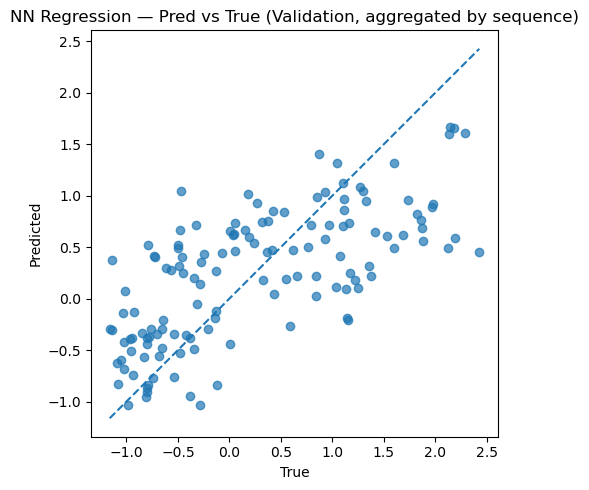

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(agg_pred_df["True"], agg_pred_df["Pred"], alpha=0.7)

min_val = min(agg_pred_df["True"].min(), agg_pred_df["Pred"].min())
max_val = max(agg_pred_df["True"].max(), agg_pred_df["Pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("NN Regression — Pred vs True (Validation, aggregated by sequence)")
plt.tight_layout()
plt.show()
